In [86]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

import lightning.pytorch as pl
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping

from pytorch_forecasting import Baseline, DeepAR, TimeSeriesDataSet
from pytorch_forecasting.metrics import SMAPE, MultivariateNormalDistributionLoss

In [87]:
device=torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [56]:
device

device(type='cuda')

In [88]:
train_df=pd.read_csv("data/train.csv")
train_df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [89]:
train_df["date"]=pd.to_datetime(train_df["date"], errors="coerce")
train_df[["store", "item"]]=train_df[["store", "item"]]. astype(str)
train_df["sales"]=pd.to_numeric(train_df["sales"], downcast="float")

In [90]:
min_date=train_df["date"].min()
train_df["time_idx"]=train_df["date"].map(lambda current_date:(current_date-min_date).days)
train_df.head()

,date,store,item,sales,time_idx
0,2013-01-01,1,1,13.0,0
1,2013-01-02,1,1,11.0,1
2,2013-01-03,1,1,14.0,2
3,2013-01-04,1,1,13.0,3
4,2013-01-05,1,1,10.0,4


In [91]:
max_encoder_length=60
max_prediction_length=20
training_cutoff=train_df["time_idx"].max()-max_prediction_length

In [92]:
training=TimeSeriesDataSet(
    train_df[lambda x:x.time_idx<=training_cutoff],
    time_idx="time_idx",
    target="sales",
    group_ids=["store", "item"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["store", "item"],
    time_varying_unknown_reals=["sales"]
)

validation=TimeSeriesDataSet.from_dataset(training, train_df, min_prediction_idx=training_cutoff+1)

In [93]:
batch_size=128

train_dataloader=training.to_dataloader(
    train=True , batch_size=batch_size , num_workers=0
)

val_dataloader=validation.to_dataloader(
    train=False, batch_size=batch_size, num_workers=0
)

In [94]:
pl.seed_everything(42)

Seed set to 42


42

In [95]:
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")

In [101]:
trainer=Trainer(
    max_epochs=30,
    enable_model_summary=True, 
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback],
    limit_train_batches=50,
    enable_checkpointing=True
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [115]:
net = DeepAR.from_dataset(
    training,
    learning_rate=0.7,
    log_interval=10,
    log_val_interval=1,
    hidden_size=30,
    rnn_layers=2,
    loss=MultivariateNormalDistributionLoss(),
)

/home/soham/Downloads/deepar/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/soham/Downloads/deepar/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [116]:
trainer.fit(
    net, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

/home/soham/Downloads/deepar/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/soham/Downloads/deepar/lightning_logs/version_4/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                   | Type                               | Params | Mode  | FLOPs
----------------------------------------------------------------------------------------------
0 | loss                   | MultivariateNormalDistributionLoss | 0      | train | 0    
1 | logging_metrics        | ModuleList                         | 0      | train | 0    
2 | embeddings             | MultiEmbedding                     | 760    | train | 0    
3 | rnn                    | LSTM                               | 13.8 K | train | 0    
4 | distribution_projector | Linear                             | 372    | train | 0    
----------------------------------------------------------------------------------------------
14.9

/home/soham/Downloads/deepar/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/soham/Downloads/deepar/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 2: 100%|██████████| 50/50 [00:01<00:00, 25.43it/s, v_num=4, train_loss_step=648.0, val_loss=604.0, train_loss_epoch=3.95e+3]


In [117]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_model = DeepAR.load_from_checkpoint(best_model_path)

In [118]:
best_model

DeepAR(
  	"categorical_groups":                {}
  	"cell_type":                         LSTM
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'sales', 'group_ids': ['store', 'item'], 'weight': None, 'max_encoder_length': 60, 'min_encoder_length': 60, 'min_prediction_idx': np.int64(0), 'min_prediction_length': 20, 'max_prediction_length': 20, 'static_categoricals': ['store', 'item'], 'static_reals': None, 'time_varying_known_categoricals': None, 'time_varying_known_reals': None, 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['sales'], 'variable_groups': None, 'constant_fill_strategy': None, 'allow_missing_timesteps': False, 'lags': None, 'add_relative_time_idx': False, 'add_target_scales': False, 'add_encoder_length': False, 'target_normalizer': EncoderNormalizer(
  		method='standard',
  		center=True,
  		max_length=None,
  		transformation=None,
  		method_kwargs={}
  	), 'categorical_encoders': {'__group_id__store': NaNLabelEnc

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


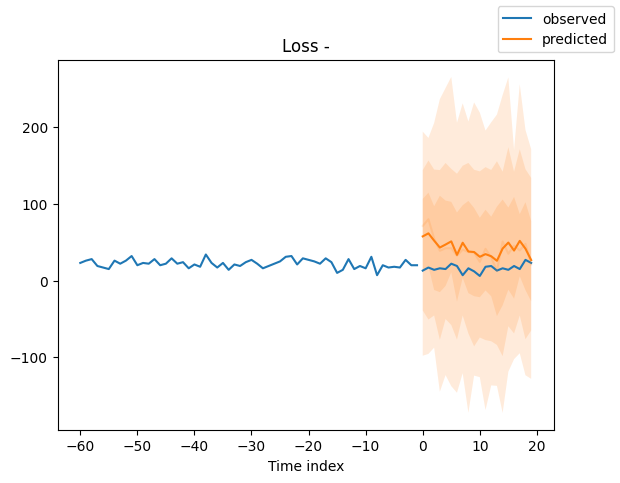

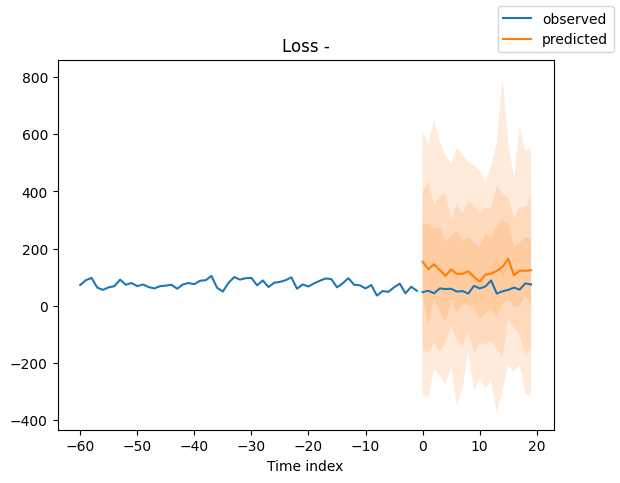

In [119]:
predictions = best_model.predict(
    val_dataloader,
    mode="raw",
    return_x=True
)

raw_predictions = predictions.output
x = predictions.x
for idx in range(2):
    best_model.plot_prediction(
        x,
        raw_predictions,
        idx=idx,
        add_loss_to_title=SMAPE()
    )